<a href="https://colab.research.google.com/github/Upeshjeengar/Stock-Price-Prediction/blob/main/time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dates=pd.date_range(start="2024-08-19",end='2024-9-19') #"yyyy-mm-dd"
dates

DatetimeIndex(['2024-08-19', '2024-08-20', '2024-08-21', '2024-08-22',
               '2024-08-23', '2024-08-24', '2024-08-25', '2024-08-26',
               '2024-08-27', '2024-08-28', '2024-08-29', '2024-08-30',
               '2024-08-31', '2024-09-01', '2024-09-02', '2024-09-03',
               '2024-09-04', '2024-09-05', '2024-09-06', '2024-09-07',
               '2024-09-08', '2024-09-09', '2024-09-10', '2024-09-11',
               '2024-09-12', '2024-09-13', '2024-09-14', '2024-09-15',
               '2024-09-16', '2024-09-17', '2024-09-18', '2024-09-19'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
dates=pd.date_range(start="2024-08-09",periods=10,freq='D') #freq=nD for n Days, nH for nHours
dates

DatetimeIndex(['2024-08-09', '2024-08-10', '2024-08-11', '2024-08-12',
               '2024-08-13', '2024-08-14', '2024-08-15', '2024-08-16',
               '2024-08-17', '2024-08-18'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
df=pd.DataFrame({'values':np.random.randint(1,100,size=(10,))},
             index=dates)
df

,values
2024-08-09,84
2024-08-10,20
2024-08-11,34
2024-08-12,88
2024-08-13,42
2024-08-14,27
2024-08-15,63
2024-08-16,67
2024-08-17,33
2024-08-18,74


<Axes: >

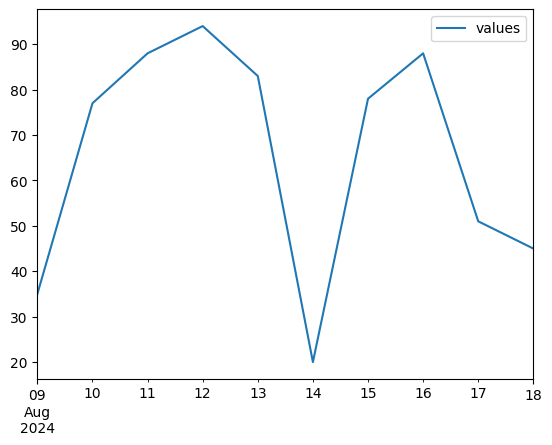

In [ ]:
df.plot()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
dates=pd.date_range(start="2024-08-09",periods=100,freq='D')
data=pd.DataFrame({'values':10+0.1*np.arange(100)+5*np.sin(2*np.pi*np.arange(100)/12)},
                  index=dates)
data

,values
2024-08-09,10.000000
2024-08-10,12.600000
2024-08-11,14.530127
2024-08-12,15.300000
2024-08-13,14.730127
...,...
2024-11-12,17.000000
2024-11-13,19.600000
2024-11-14,22.200000
2024-11-15,24.130127


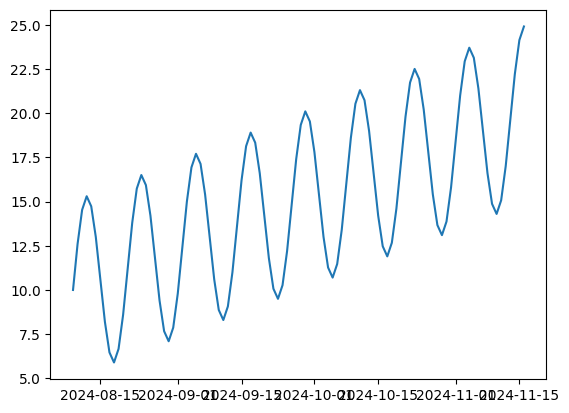

In [ ]:
plt.plot(dates,data['values'])

seasonal decompose plots


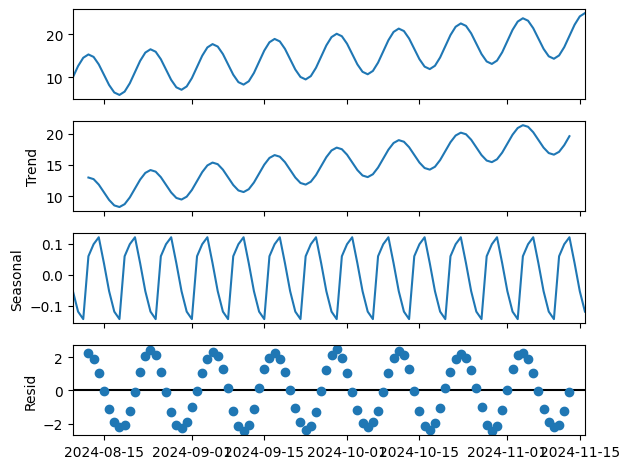

In [ ]:

decomposition=seasonal_decompose(data,model='additive')
#Seasonal decomposition using moving averages represent a time series as a sum
#(or, sometimes, a product) of three components – the linear trend, the periodic (seasonal)
#component, and random residuals.
decomposition.plot()
print('seasonal decompose plots')

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data,order=(5,1,0))
model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
data_pred=model.fit().forecast(20)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


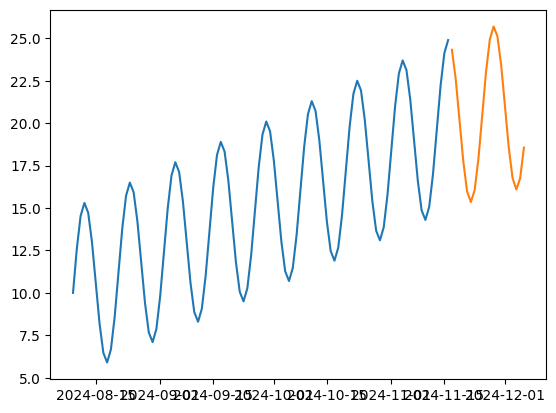

In [ ]:
plt.plot(data)
plt.plot(data_pred)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
sarima=SARIMAX(data)

In [ ]:
data_pred_sarima=sarima.fit().forecast(20)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


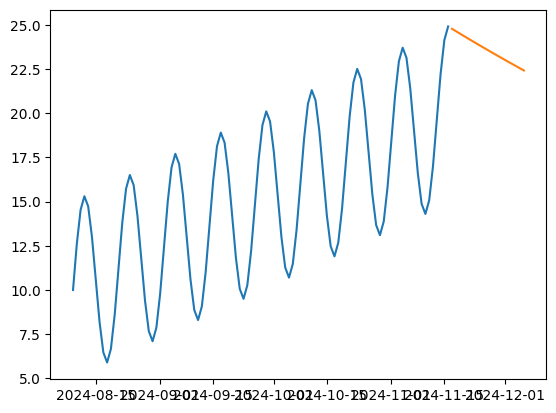

In [ ]:
plt.plot(data)
plt.plot(data_pred_sarima)

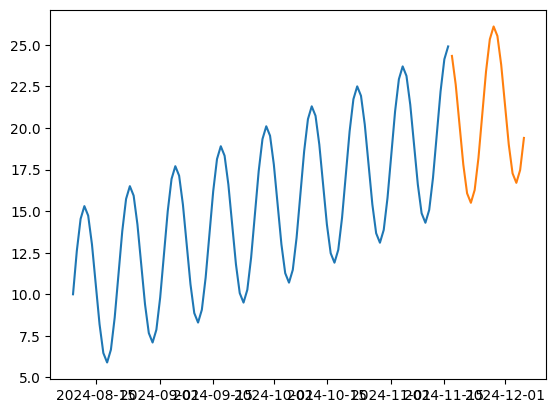

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
model=AutoReg(data,lags=5)
pred=model.fit().forecast(20)
plt.plot(data)
plt.plot(pred)

In [ ]:
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
data.values.reshape(100,),acf(data),pacf(data)

(array([10.        , 12.6       , 14.53012702, 15.3       , 14.73012702,
        13.        , 10.6       ,  8.2       ,  6.46987298,  5.9       ,
         6.66987298,  8.6       , 11.2       , 13.8       , 15.73012702,
        16.5       , 15.93012702, 14.2       , 11.8       ,  9.4       ,
         7.66987298,  7.1       ,  7.86987298,  9.8       , 12.4       ,
        15.        , 16.93012702, 17.7       , 17.13012702, 15.4       ,
        13.        , 10.6       ,  8.86987298,  8.3       ,  9.06987298,
        11.        , 13.6       , 16.2       , 18.13012702, 18.9       ,
        18.33012702, 16.6       , 14.2       , 11.8       , 10.06987298,
         9.5       , 10.26987298, 12.2       , 14.8       , 17.4       ,
        19.33012702, 20.1       , 19.53012702, 17.8       , 15.4       ,
        13.        , 11.26987298, 10.7       , 11.46987298, 13.4       ,
        16.        , 18.6       , 20.53012702, 21.3       , 20.73012702,
        19.        , 16.6       , 14.2       , 12.4

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# if p-value > 0.05, the series is non-stationary and needs differencing
if result[1] > 0.05:
    print("needs differencing")
else:
    print("time series is stationary")

ADF Statistic: 0.10990751458034521
p-value: 0.9667310523341258
needs differencing


# Predicting Time Series Data with Machine Learning, Generative AI, and Deep Learning

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from datetime import date
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
st=date(year=2020,month=8,day=22)
en=date(year=2024,month=9,day=2)

data=yf.download('HDFCBANK.NS',start=st,end=en)
data["Date"]=data.index
data.tail()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,Date
Date,,,,,,,
2024-08-26,1632.199951,1647.949951,1632.199951,1639.949951,1639.949951,11182133,2024-08-26
2024-08-27,1643.400024,1647.400024,1632.199951,1637.750000,1637.750000,17886622,2024-08-27
2024-08-28,1637.750000,1639.750000,1630.199951,1637.099976,1637.099976,13460594,2024-08-28
2024-08-29,1642.000000,1644.400024,1631.150024,1638.550049,1638.550049,24526302,2024-08-29
2024-08-30,1656.000000,1662.000000,1621.150024,1636.900024,1636.900024,222671050,2024-08-30


In [ ]:
data=data[["Close","Date"]]
data

,Close,Date
Date,,
2020-08-24,1117.050049,2020-08-24
2020-08-25,1119.699951,2020-08-25
2020-08-26,1118.449951,2020-08-26
2020-08-27,1112.099976,2020-08-27
2020-08-28,1114.500000,2020-08-28
...,...,...
2024-08-26,1639.949951,2024-08-26
2024-08-27,1637.750000,2024-08-27
2024-08-28,1637.099976,2024-08-28


In [ ]:
data.reset_index(drop=True, inplace=True)
data

,Close,Date
0,1117.050049,2020-08-24
1,1119.699951,2020-08-25
2,1118.449951,2020-08-26
3,1112.099976,2020-08-27
4,1114.500000,2020-08-28
...,...,...
990,1639.949951,2024-08-26
991,1637.750000,2024-08-27
992,1637.099976,2024-08-28
993,1638.550049,2024-08-29


In [ ]:
data,test=data[:245],data[245:]
data

,Close,Date
0,1117.050049,2020-08-24
1,1119.699951,2020-08-25
2,1118.449951,2020-08-26
3,1112.099976,2020-08-27
4,1114.500000,2020-08-28
...,...,...
240,1507.650024,2021-08-10
241,1494.949951,2021-08-11
242,1501.400024,2021-08-12
243,1526.199951,2021-08-13


In [ ]:
test

,Close,Date
245,1625.050049,2024-08-23
246,1639.949951,2024-08-26
247,1637.750000,2024-08-27
248,1637.099976,2024-08-28
249,1638.550049,2024-08-29
250,1636.900024,2024-08-30


In [ ]:
model = ARIMA(data["Close"], order=(1, 1, 1))  # Replace (p, d, q) with your chosen values
arima_pred = model.fit().forecast(6)
arima_pred

,predicted_mean
245,1632.312866
246,1631.327346
247,1632.286305
248,1631.353191
249,1632.261156
250,1631.377662


In [ ]:
arima_mse,arima_r2=mean_squared_error(arima_pred,test["Close"]),r2_score(arima_pred,test["Close"])

In [ ]:
arima_r2,arima_mse

(-197.29960026766508, 43.33699981988323)

In [ ]:
MSE=dict()
MSE["ARIMA"]=arima_mse

## SARIMA (Seasonal ARIMA)



In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model=SARIMAX(data["Close"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))  # (p,d,q) (P,D,Q,s)
sarima_pred=model.fit().forecast(6)
sarima_pred

,predicted_mean
245,1629.732249
246,1631.999921
247,1631.006876
248,1625.286649
249,1629.788683
250,1624.923422


In [ ]:
sarima_mse,sarima_r2 = mean_squared_error(sarima_pred,test["Close"]),r2_score(sarima_pred,test["Close"])

In [ ]:
sarima_mse,sarima_r2

(81.72515233587495, -10.062070178866552)

In [ ]:
MSE["SARIMA"]=sarima_mse

In [ ]:
#Prophet
from prophet import Prophet
model=Prophet()
prophet_data=pd.DataFrame()
prophet_data["ds"]=data["Date"]
prophet_data["y"]=data["Close"]
prophet_data.head()
model.fit(prophet_data)
future=model.make_future_dataframe(periods=6)
future

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp68uvig85/8i6d_zrt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp68uvig85/wpr5bt7z.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=77346', 'data', 'file=/tmp/tmp68uvig85/8i6d_zrt.json', 'init=/tmp/tmp68uvig85/wpr5bt7z.json', 'output', 'file=/tmp/tmp68uvig85/prophet_model5ezx716v/prophet_model-20241007070739.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:07:39 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:07:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds
0,2023-08-22
1,2023-08-23
2,2023-08-24
3,2023-08-25
4,2023-08-28
...,...
246,2024-08-24
247,2024-08-25
248,2024-08-26
249,2024-08-27


In [ ]:
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

            ds         yhat   yhat_lower   yhat_upper
0   2023-08-22  1598.145570  1537.935012  1657.239547
1   2023-08-23  1594.837878  1540.185250  1653.414977
2   2023-08-24  1595.064752  1535.898443  1652.388745
3   2023-08-25  1597.293849  1540.883321  1653.387677
4   2023-08-28  1596.301256  1538.936845  1655.155359
..         ...          ...          ...          ...
246 2024-08-24  1656.349534  1603.684866  1714.169095
247 2024-08-25  1657.632449  1598.002137  1715.457081
248 2024-08-26  1678.821815  1621.506109  1739.164993
249 2024-08-27  1674.006300  1613.092179  1735.402960
250 2024-08-28  1673.305317  1615.987768  1727.642462

[251 rows x 4 columns]


In [ ]:
forecast["yhat"][245:]

,yhat
245,1671.994283
246,1656.349534
247,1657.632449
248,1678.821815
249,1674.006300
250,1673.305317


In [ ]:
prophet_mse,prophet_r2 = mean_squared_error(forecast["yhat"][245:],test["Close"]),r2_score(forecast["yhat"][245:],test["Close"])

In [ ]:
MSE["Prophet"]=prophet_mse
prophet_mse,prophet_r2

(1198.537024374937, -15.429849093301844)

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten, LeakyReLU, Reshape
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

# Load your time series data
time_series_data = data

# Prepare data for GAN
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(time_series_data['Close'].values.reshape(-1, 1))

X_train, y_train = create_dataset(scaled_data, time_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

# GAN components
def build_generator():
    model = Sequential()
    model.add(Dense(100, input_dim=time_step))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(time_step, activation='tanh'))
    model.add(Reshape((time_step, 1)))
    return model

def build_discriminator():
    model = Sequential()
    model.add(LSTM(50, input_shape=(time_step, 1)))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Build and compile the discriminator
discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5), metrics=['accuracy'])

# Build the generator
generator = build_generator()

# The generator takes noise as input and generates data
z = Input(shape=(time_step,))
generated_data = generator(z)

# For the combined model, we will only train the generator
discriminator.trainable = False

# The discriminator takes generated data as input and determines validity
validity = discriminator(generated_data)

# The combined model (stacked generator and discriminator)
combined = Model(z, validity)
combined.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

# Training the GAN
epochs = 1000
batch_size = 32
valid = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

for epoch in range(epochs):
    # ---------------------
    #  Train Discriminator
    # ---------------------

    # Select a random batch of real data
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_data = X_train[idx]

    # Generate a batch of fake data
    noise = np.random.normal(0, 1, (batch_size, time_step))
    gen_data = generator.predict(noise)

    # Train the discriminator
    d_loss_real = discriminator.train_on_batch(real_data, valid)
    d_loss_fake = discriminator.train_on_batch(gen_data, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ---------------------
    #  Train Generator
    # ---------------------

    noise = np.random.normal(0, 1, (batch_size, time_step))

    # Train the generator (to have the discriminator label samples as valid)
    g_loss = combined.train_on_batch(noise, valid)

    # Print the progress
    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss[0]} | D accuracy: {100*d_loss[1]}] [G loss: {g_loss}]")

# Make predictions
noise = np.random.normal(0, 1, (1, time_step))
generated_prediction = generator.predict(noise)

In [ ]:
generated_prediction = generated_prediction.reshape(-1, 1) # Reshape to a 2D array
generated_prediction = scaler.inverse_transform(generated_prediction)
print(generated_prediction)

[[1736.8801]
 [1658.8577]
 [1601.1365]
 [1634.1262]
 [1639.9011]
 [1742.5973]
 [1754.565 ]
 [1752.044 ]
 [1757.4897]
 [1758.7043]]


In [ ]:
MSE["GAN"]=mean_squared_error(generated_prediction[:6],test["Close"])
MSE["GAN"]

4231.099812639256

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Load your time series data
time_series_data = data

# Prepare data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(time_series_data['Close'].values.reshape(-1, 1))

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=1, epochs=50)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
print(test_predict[:6])

[[1662.5837]
 [1669.9502]
 [1648.7684]
 [1679.4725]
 [1693.7288]
 [1736.7645]]


In [ ]:
MSE["LSTM"]=mean_squared_error(test_predict[:6],test["Close"])
MSE["LSTM"]

2873.872321460624

In [ ]:
for i,j in MSE.items():
  print(i,j)

ARIMA 43.33699981988323
SARIMA 81.72515233587495
Prophet 1198.537024374937
GAN 4231.099812639256
LSTM 2873.872321460624


# LSTM


In [ ]:
data=[data,test]
data=pd.concat(data)
data

,Close,Date
0,1582.699951,2023-08-22
1,1586.599976,2023-08-23
2,1579.300049,2023-08-24
3,1561.500000,2023-08-25
4,1577.750000,2023-08-28
...,...,...
246,1639.949951,2024-08-26
247,1637.750000,2024-08-27
248,1637.099976,2024-08-28
249,1638.550049,2024-08-29


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(np.array(data['Close']).reshape(-1, 1))

In [ ]:
training_data_len = int(np.ceil( len(data) * .85 ))

train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

x_train=np.array(x_train)
y_train=np.array(y_train)

In [ ]:
test_data = scaled_data[training_data_len - 60:, :]

# Create the data sets x_test and y_test
x_test = []
y_test = []

# Loop through the test_data to create x_test and y_test
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    y_test.append(test_data[i, 0])  # Use scaled data for y_test as well

# Convert the data to a numpy array
x_test = np.array(x_test)
y_test = np.array(y_test)  # Convert y_test to numpy array as well

# Reshape the data to be 3D for LSTM input (samples, timesteps, features)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping

model=Sequential()
model.add(LSTM(128,return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(64,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25,activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam',loss='mean_squared_error')

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 60, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 0.0010
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - val_loss: 9.6863e-04
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - val_loss: 9.4602e-04
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - val_loss: 9.4637e-04
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - val_loss: 9.3367e-04
Epoch 9/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - val_loss: 9.1161e-04
Epoch 10/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - val_loss: 9.2851e-04
Epoch 11/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 9.5006e-04
Epoch 12/500
25/25 ━━━━━━

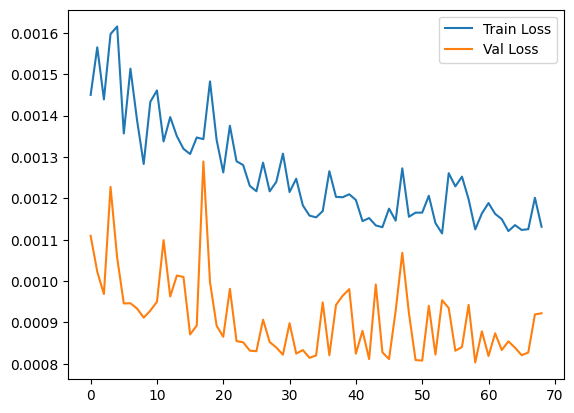

In [ ]:
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

history=model.fit(x_train,y_train,batch_size=32, epochs=500, validation_data=(x_test,y_test),callbacks=[early_stop])

import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [ ]:
# Get the models predicted price values
predictions = model.predict(x_test)
# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


0.1743178315155368

In [ ]:
predictions = scaler.inverse_transform(predictions)

<ipython-input-59-bac245597b66>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


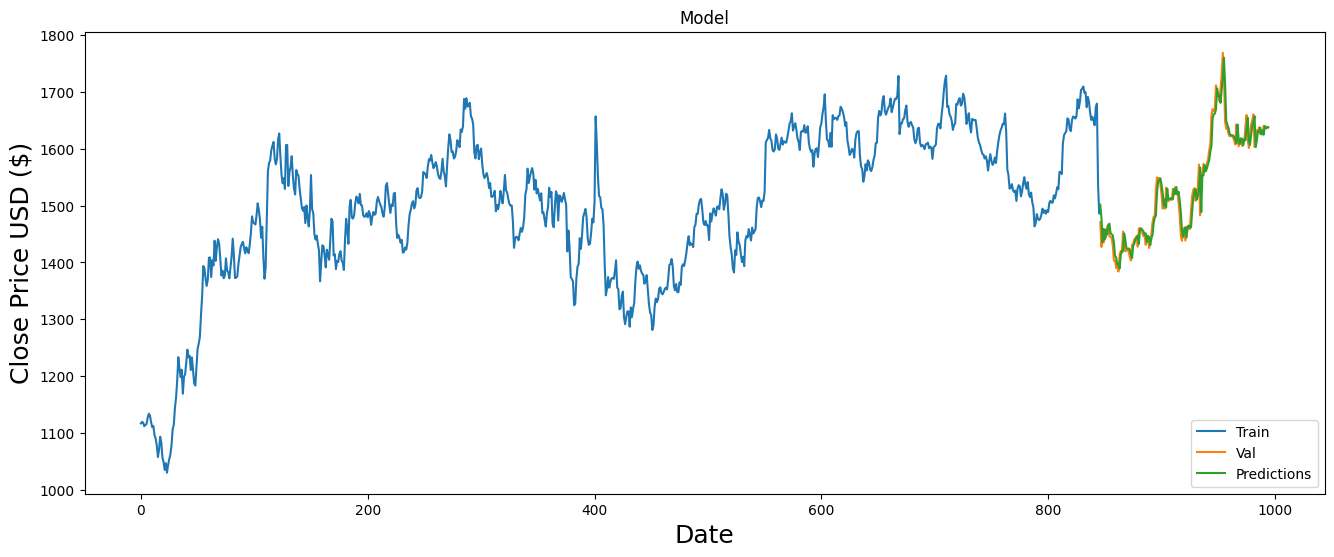

In [ ]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
from sklearn.metrics import r2_score
r2_score(valid['Close'], valid['Predictions'])

0.9486002221923414

In [ ]:
mean_squared_error(valid['Close'], valid['Predictions'])

437.7814872902912